# Feature Importance Analysis (B)

## Objective
Determine which features contribute most to the classification of Seizure vs Healthy vs Inter-ictal signals.

## Method
We use a `RandomForestClassifier` to compute standard Gini importance (`feature_importances_`).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import os

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Data

In [2]:
data_path = '../data/processed/Bonn_EEG_Train.csv'

if not os.path.exists(data_path):
    print("Data file not found!")
else:
    df = pd.read_csv(data_path)
    print(f"Data loaded: {df.shape}")

Data loaded: (26312, 192)


## 2. Prepare X and y

In [3]:
# Features
feature_cols = [
    'RMS', 'ZCR', 
    'Hjorth_Activity', 'Hjorth_Mobility', 'Hjorth_Complexity',
    'Envelope_Mean', 'Envelope_Max', 
    'Deriv1_Mean', 'Deriv1_Std', 
    'Deriv2_Mean', 'Deriv2_Std'
]

available_cols = [c for c in feature_cols if c in df.columns]
X = df[available_cols]

# Labels (Convert One-Hot to Class Index)
y_cols = [c for c in df.columns if c.startswith('y_')]
y = df[y_cols].idxmax(axis=1).apply(lambda s: int(s.split('_')[1]))

print("Features X shape:", X.shape)
print("Labels y shape:", y.shape)
print("Class distribution:\n", y.value_counts())

Features X shape: (26312, 11)
Labels y shape: (26312,)
Class distribution:
 1    10560
0    10472
2     5280
Name: count, dtype: int64


## 3. Train Random Forest

In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 4. Extract and Plot Importances

              Feature  Importance
3     Hjorth_Mobility    0.278113
2     Hjorth_Activity    0.135249
4   Hjorth_Complexity    0.109198
6        Envelope_Max    0.099843
10         Deriv2_Std    0.091518
0                 RMS    0.088501
5       Envelope_Mean    0.065245
8          Deriv1_Std    0.060859
1                 ZCR    0.044478
7         Deriv1_Mean    0.013666
9         Deriv2_Mean    0.013330


/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_94066/1103451507.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


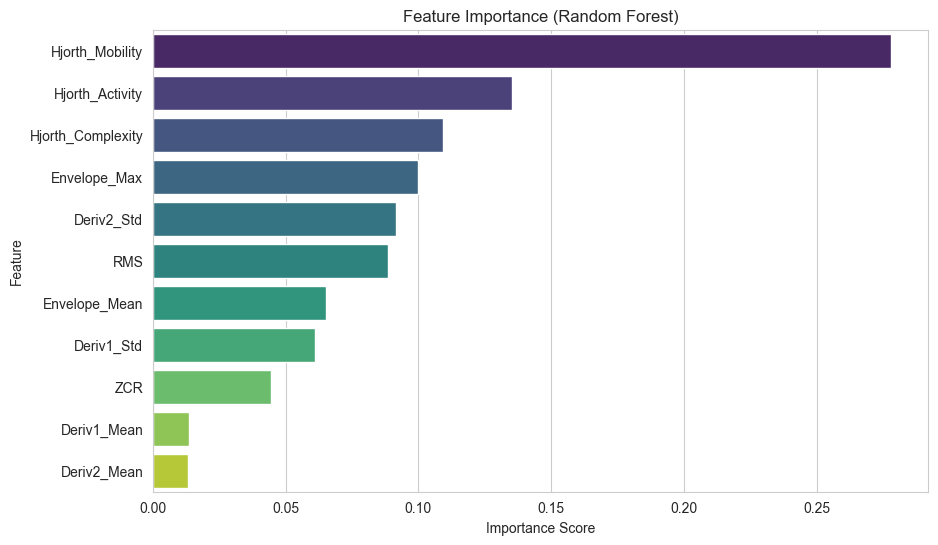

In [5]:
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': available_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()